<a href="https://colab.research.google.com/github/kej534923-maker/ECON5200-Applied-Data-Analytics/blob/main/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase1

In [2]:
# Step 1: Install required packages
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

# Step 2: Import libraries
import wbgapi as wb
import pandas as pd
import numpy as np

# Scikit-learn modules
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, LogisticRegression
from sklearn.linear_model import lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, f1_score, precision_score, recall_score
)

# Statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Environment setup complete!")

✅ Environment setup complete!


In [3]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [4]:
# ============================================================
# PART 1B: Reshape, Clean, Build Outcomes, Split, Scale
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Start from raw_data
# raw_data currently has columns like:
# ['country_code', 'series', 'YR2013', ..., 'YR2019']
# -----------------------------
df = raw_data.copy()

# If country_code / series are in index, reset
if isinstance(df.index, pd.MultiIndex):
    df = df.reset_index()
else:
    df = df.reset_index()

print("Columns before processing:")
print(df.columns.tolist())

# -----------------------------
# 2. Rename key columns if needed
# -----------------------------
rename_map = {}
for col in df.columns:
    c = str(col).lower()
    if c in ['economy', 'country', 'economy_code', 'index']:
        rename_map[col] = 'country_code'
    elif c in ['series', 'indicator', 'series_code']:
        rename_map[col] = 'series'

df = df.rename(columns=rename_map)

print("\nColumns after rename:")
print(df.columns.tolist())

# -----------------------------
# 3. Map indicator codes in 'series' to readable names
# -----------------------------
df['series'] = df['series'].map(INDICATORS)

# Drop rows whose indicator codes are not in INDICATORS
df = df.dropna(subset=['series']).copy()

# -----------------------------
# 4. Convert wide year columns to long format
# -----------------------------
year_cols = [c for c in df.columns if str(c).startswith('YR')]
print("\nYear columns found:", year_cols)

df_long = df.melt(
    id_vars=['country_code', 'series'],
    value_vars=year_cols,
    var_name='year',
    value_name='value'
)

# Convert "YR2013" -> 2013
df_long['year'] = df_long['year'].str.replace('YR', '', regex=False).astype(int)

# Make numeric
df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce')

print("\nLong format preview:")
display(df_long.head())

# -----------------------------
# 5. Pivot so each row = country-year, each column = indicator
# -----------------------------
panel_df = df_long.pivot_table(
    index=['country_code', 'year'],
    columns='series',
    values='value',
    aggfunc='mean'
).reset_index()

# Remove column name left by pivot
panel_df.columns.name = None

print("\nPanel data preview:")
display(panel_df.head())

# -----------------------------
# 6. Collapse to country-level means (2013–2019 average)
# -----------------------------
country_df = panel_df.groupby('country_code', as_index=False).mean(numeric_only=True)

print("\nCountry-level data preview:")
display(country_df.head())

# -----------------------------
# 7. Drop countries missing >40% of indicators
# -----------------------------
all_indicator_cols = [c for c in country_df.columns if c not in ['country_code', 'year']]
country_missing_rate = country_df[all_indicator_cols].isna().mean(axis=1)
country_df = country_df.loc[country_missing_rate <= 0.40].copy()

# -----------------------------
# 8. Drop indicators missing >40% of countries
# -----------------------------
indicator_missing_rate = country_df[all_indicator_cols].isna().mean(axis=0)
kept_cols = indicator_missing_rate[indicator_missing_rate <= 0.40].index.tolist()

# Make sure outcome variable stays
if OUTCOME_VAR not in kept_cols and OUTCOME_VAR in country_df.columns:
    kept_cols.append(OUTCOME_VAR)

country_df = country_df[['country_code'] + kept_cols].copy()

# -----------------------------
# 9. Median-impute remaining missing values
# -----------------------------
for col in kept_cols:
    country_df[col] = country_df[col].fillna(country_df[col].median())

# -----------------------------
# 10. Define outcomes
# -----------------------------
if OUTCOME_VAR not in country_df.columns:
    raise ValueError(
        f"{OUTCOME_VAR} not found after cleaning. "
        "Check whether the outcome indicator was downloaded correctly."
    )

country_df['crisis'] = (country_df[OUTCOME_VAR] < 0).astype(int)

# -----------------------------
# 11. Define X and y
# -----------------------------
feature_cols = [c for c in country_df.columns if c not in ['country_code', OUTCOME_VAR, 'crisis']]

print(f"\nNumber of predictors remaining after cleaning: {len(feature_cols)}")
if len(feature_cols) < 25:
    print("WARNING: Fewer than 25 predictors remain after cleaning.")

X = country_df[feature_cols].copy()
y_reg = country_df[OUTCOME_VAR].copy()
y_clf = country_df['crisis'].copy()

# -----------------------------
# 12. Train-test split (70/30)
# -----------------------------
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf,
    test_size=0.30,
    random_state=42
)

# -----------------------------
# 13. Standardize features using training data only
# -----------------------------
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# -----------------------------
# 14. Print required summary stats
# -----------------------------
n_countries = country_df.shape[0]
n_predictors = len(feature_cols)
n_crisis = int(country_df['crisis'].sum())
n_noncrisis = int((country_df['crisis'] == 0).sum())
crisis_base_rate = country_df['crisis'].mean()

print("\n" + "="*60)
print("FINAL DATASET SUMMARY")
print("="*60)
print(f"Final dataset dimensions: {n_countries} countries × {n_predictors} predictors")
print(f"Crisis countries: {n_crisis}")
print(f"Non-crisis countries: {n_noncrisis}")
print(f"Crisis base rate: {crisis_base_rate:.3f}")

print("\nTrain/Test Split")
print("-"*60)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

print("\nFirst 5 rows of cleaned country-level dataset:")
display(country_df.head())

print("\nFirst 5 rows of scaled X_train:")
display(X_train_scaled.head())

Columns before processing:
['economy', 'series', 'YR2013', 'YR2014', 'YR2015', 'YR2016', 'YR2017', 'YR2018', 'YR2019']

Columns after rename:
['country_code', 'series', 'YR2013', 'YR2014', 'YR2015', 'YR2016', 'YR2017', 'YR2018', 'YR2019']

Year columns found: ['YR2013', 'YR2014', 'YR2015', 'YR2016', 'YR2017', 'YR2018', 'YR2019']

Long format preview:


,country_code,series,year,value
0,ABW,arable_land_pct,2013,11.111111
1,ABW,current_account_pct_gdp,2013,-11.813209
2,ABW,royalties_receipts,2013,75.054503
3,ABW,fdi_inflows_pct_gdp,2013,9.974457
4,ABW,electricity_access_pct,2013,100.000000



Panel data preview:


,country_code,year,adult_literacy_rate,agriculture_pct_gdp,arable_land_pct,atms_per100k,current_account_pct_gdp,domestic_credit_pct_gdp,education_expenditure_pct_gdp,electricity_access_pct,...,real_interest_rate,renewable_energy_pct,royalties_receipts,secondary_enrollment_gross,tariff_rate_avg,tertiary_enrollment_gross,trade_cpia,trade_pct_gdp,unemployment_rate,urbanization_pct
0,ABW,2013,NaN,0.017817,11.111111,124.135271,-11.813209,NaN,6.44296,100.0,...,10.709709,6.9,75.054503,NaN,10.16,17.125870,NaN,155.731904,NaN,63.638291
1,ABW,2014,NaN,0.014813,11.111111,118.048269,-4.658577,NaN,5.85128,100.0,...,6.373474,6.9,67.345643,NaN,NaN,17.751900,NaN,156.491053,NaN,63.439253
2,ABW,2015,NaN,0.012520,11.111111,119.304960,3.994142,NaN,5.88827,100.0,...,4.426358,6.7,17247.742744,NaN,9.77,16.731239,NaN,140.493001,NaN,63.228837
3,ABW,2016,NaN,0.018612,11.111111,126.468143,4.731774,NaN,5.49136,100.0,...,7.467580,7.0,33607.017326,NaN,10.27,17.141621,NaN,136.887263,NaN,63.007788
4,ABW,2017,NaN,0.023919,11.111111,125.425343,1.119796,NaN,4.45582,100.0,...,6.143280,6.8,8565.609832,NaN,9.99,NaN,NaN,138.716620,NaN,62.776849



Country-level data preview:


,country_code,year,adult_literacy_rate,agriculture_pct_gdp,arable_land_pct,atms_per100k,current_account_pct_gdp,domestic_credit_pct_gdp,education_expenditure_pct_gdp,electricity_access_pct,...,real_interest_rate,renewable_energy_pct,royalties_receipts,secondary_enrollment_gross,tariff_rate_avg,tertiary_enrollment_gross,trade_cpia,trade_pct_gdp,unemployment_rate,urbanization_pct
0,ABW,2016.0,NaN,0.018337,11.111111,123.843123,-0.669091,NaN,5.301927,100.000000,...,6.161741,7.314286,3.918354e+05,138.575188,10.186667,17.187657,NaN,143.586678,NaN,62.988008
1,AFE,2016.0,70.821429,12.439481,8.096816,8.029037,NaN,101.530133,4.677735,37.718154,...,NaN,61.605147,2.582984e+08,42.748069,NaN,8.517323,3.481830,55.661535,7.096626,34.887403
2,AFG,2016.0,33.750000,23.651344,11.900053,1.128242,-19.805290,NaN,3.858524,87.928571,...,13.222770,18.657143,1.606758e+05,54.776075,7.665000,9.196780,3.357143,NaN,9.792429,24.585807
3,AFW,2016.0,56.718571,20.565694,11.932068,4.864819,NaN,NaN,2.888076,49.199649,...,NaN,75.868295,3.419290e+07,43.429490,NaN,9.424783,3.807143,NaN,4.134629,48.171470
4,AGO,2016.0,66.134998,12.971708,4.166084,17.853955,0.248949,23.625157,2.900706,41.142857,...,4.250726,49.357143,1.279839e+07,54.416799,9.648333,9.263161,3.500000,59.174363,16.513714,64.327626



Number of predictors remaining after cleaning: 27

FINAL DATASET SUMMARY
Final dataset dimensions: 238 countries × 27 predictors
Crisis countries: 38
Non-crisis countries: 200
Crisis base rate: 0.160

Train/Test Split
------------------------------------------------------------
X_train shape: (166, 27)
X_test shape:  (72, 27)
X_train_scaled shape: (166, 27)
X_test_scaled shape:  (72, 27)

First 5 rows of cleaned country-level dataset:


,country_code,adult_literacy_rate,agriculture_pct_gdp,arable_land_pct,atms_per100k,current_account_pct_gdp,education_expenditure_pct_gdp,electricity_access_pct,exchange_rate_official,fdi_inflows_pct_gdp,...,private_credit_pct_gdp,renewable_energy_pct,royalties_receipts,secondary_enrollment_gross,tariff_rate_avg,tertiary_enrollment_gross,trade_pct_gdp,unemployment_rate,urbanization_pct,crisis
0,ABW,87.383592,0.018337,11.111111,123.843123,-0.669091,5.301927,100.000000,1.790000,3.551600,...,58.016290,7.314286,3.918354e+05,138.575188,10.186667,17.187657,143.586678,5.958071,62.988008,0
1,AFE,70.821429,12.439481,8.096816,8.029037,-2.814634,4.677735,37.718154,9.958343,1.994010,...,37.151340,61.605147,2.582984e+08,42.748069,6.734000,8.517323,55.661535,7.096626,34.887403,0
2,AFG,33.750000,23.651344,11.900053,1.128242,-19.805290,3.858524,87.928571,65.640378,0.415848,...,3.676093,18.657143,1.606758e+05,54.776075,7.665000,9.196780,69.356608,9.792429,24.585807,1
3,AFW,56.718571,20.565694,11.932068,4.864819,-2.814634,2.888076,49.199649,9.958343,2.024465,...,13.585211,75.868295,3.419290e+07,43.429490,6.734000,9.424783,69.356608,4.134629,48.171470,0
4,AGO,66.134998,12.971708,4.166084,17.853955,0.248949,2.900706,41.142857,180.305048,-1.996599,...,16.293914,49.357143,1.279839e+07,54.416799,9.648333,9.263161,59.174363,16.513714,64.327626,1



First 5 rows of scaled X_train:


,adult_literacy_rate,agriculture_pct_gdp,arable_land_pct,atms_per100k,current_account_pct_gdp,education_expenditure_pct_gdp,electricity_access_pct,exchange_rate_official,fdi_inflows_pct_gdp,govt_expenditure_pct_gdp,...,population_growth,private_credit_pct_gdp,renewable_energy_pct,royalties_receipts,secondary_enrollment_gross,tariff_rate_avg,tertiary_enrollment_gross,trade_pct_gdp,unemployment_rate,urbanization_pct
128,-0.313507,0.789273,-0.638745,-0.543175,-1.123742,-1.082588,0.244456,2.279939,-0.059968,-1.323723,...,0.127852,-0.258615,0.826632,-0.209872,-0.840573,-1.058001,-0.987432,0.082664,-0.960963,-1.143173
250,0.256391,-1.001660,0.185792,-0.215148,0.071639,0.403282,0.653376,-0.220802,-0.169427,-0.369181,...,-0.507135,-0.076854,-0.840503,9.623263,0.568856,-0.771815,1.797374,-1.094290,-0.440579,0.979102
165,-1.398552,1.195086,-1.083066,-0.833107,-1.769617,-1.326754,-1.602262,-0.210824,-0.071489,-0.063556,...,1.346686,-0.874154,-0.143150,-0.211019,-1.987198,1.178841,-1.415416,0.025938,0.538695,-0.280884
5,1.051145,0.976980,0.593562,-0.319401,-0.857861,-0.529846,0.651732,-0.186360,-0.021084,-0.246689,...,-2.314567,-0.528069,0.280146,-0.210423,0.654816,-1.316896,0.723116,-0.198110,1.422971,-0.156527
61,0.831155,-0.156003,-0.249847,-0.491725,-0.038375,-0.608612,0.533951,-0.218072,-0.165091,-0.063556,...,-0.483676,2.084795,-0.628194,-0.209872,0.076644,-0.112044,-0.023122,-0.738913,-0.650669,-0.169646


In [5]:
# ============================================================
# STEP 1.1: Demonstrating OLS Overfitting
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Fit OLS (Linear Regression)
ols = LinearRegression()
ols.fit(X_train_scaled, y_train_reg)

# 2. Predictions
y_train_pred = ols.predict(X_train_scaled)
y_test_pred = ols.predict(X_test_scaled)

# 3. R² scores
r2_train = r2_score(y_train_reg, y_train_pred)
r2_test = r2_score(y_test_reg, y_test_pred)

# 4. Gap
r2_gap = r2_train - r2_test

# 5. p/n ratio (IMPORTANT)
p = X_train_scaled.shape[1]   # number of predictors
n = X_train_scaled.shape[0]   # number of observations
pn_ratio = p / n

# 6. Print results
print("="*50)
print("OLS OVERFITTING DIAGNOSTICS")
print("="*50)
print(f"Training R²: {r2_train:.4f}")
print(f"Test R²:     {r2_test:.4f}")
print(f"R² Gap:      {r2_gap:.4f}")

print("\nModel Complexity")
print("-"*50)
print(f"Number of predictors (p): {p}")
print(f"Number of observations (n): {n}")
print(f"p/n ratio: {pn_ratio:.3f}")

OLS OVERFITTING DIAGNOSTICS
Training R²: 0.6032
Test R²:     -0.8864
R² Gap:      1.4896

Model Complexity
--------------------------------------------------
Number of predictors (p): 27
Number of observations (n): 166
p/n ratio: 0.163


The OLS model exhibits clear signs of overfitting. The training R² is substantially higher than the test R², resulting in a large generalization gap. This is partly driven by a relatively high predictor-to-observation ratio (p/n), which increases model flexibility. With many predictors relative to observations, OLS has high variance and can fit noise in the training data, effectively using too many degrees of freedom. As a result, the model achieves low bias on the training set but performs poorly out-of-sample due to high variance.

In [6]:
# ============================================================
# STEP 1.2: Ridge and Lasso to the Rescue
# ============================================================

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# -----------------------------
# 1. Define lambda grid
# -----------------------------
alphas = np.logspace(-3, 3, 100)

# -----------------------------
# 2. Ridge Regression
# -----------------------------
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_scaled, y_train_reg)

ridge_alpha = ridge.alpha_

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

ridge_r2_train = r2_score(y_train_reg, ridge_train_pred)
ridge_r2_test = r2_score(y_test_reg, ridge_test_pred)

ridge_rmse_test = np.sqrt(mean_squared_error(y_test_reg, ridge_test_pred))

# Ridge不会真正变成0（一般）
ridge_nonzero = np.sum(np.abs(ridge.coef_) > 1e-6)

# -----------------------------
# 3. Lasso Regression
# -----------------------------
lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train_reg)

lasso_alpha = lasso.alpha_

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

lasso_r2_train = r2_score(y_train_reg, lasso_train_pred)
lasso_r2_test = r2_score(y_test_reg, lasso_test_pred)

lasso_rmse_test = np.sqrt(mean_squared_error(y_test_reg, lasso_test_pred))

lasso_nonzero = np.sum(lasso.coef_ != 0)

# -----------------------------
# 4. OLS (reuse from Step 1.1)
# -----------------------------
ols_alpha = 0  # no regularization

ols_nonzero = X_train_scaled.shape[1]  # all features

ols_rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_test_pred))

# -----------------------------
# 5. Build comparison table
# -----------------------------
comparison_df = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'Lambda (α*)': [ols_alpha, ridge_alpha, lasso_alpha],
    'Non-zero Predictors': [ols_nonzero, ridge_nonzero, lasso_nonzero],
    'Training R²': [r2_train, ridge_r2_train, lasso_r2_train],
    'Test R²': [r2_test, ridge_r2_test, lasso_r2_test],
    'Test RMSE': [ols_rmse_test, ridge_rmse_test, lasso_rmse_test]
})

print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.round(4))

MODEL COMPARISON
   Model  Lambda (α*)  Non-zero Predictors  Training R²  Test R²  Test RMSE
0    OLS       0.0000                   27       0.6032  -0.8864     2.9015
1  Ridge      46.4159                   27       0.5608  -0.1054     2.2211
2  Lasso       0.0658                   18       0.5736  -0.3565     2.4604


I would recommend the Ridge model for operational GDP growth forecasting. Ridge regression reduces variance by shrinking coefficients, which improves out-of-sample performance while only introducing a small amount of bias. Lasso, on the other hand, enforces sparsity by setting some coefficients exactly to zero, which increases bias but can improve interpretability. In this setting, Ridge provides a better bias-variance tradeoff by stabilizing predictions without overly discarding useful information.

LASSO ENTRY ORDER
First predictor to enter the model: inflation_cpi
Entry lambda (highest λ where coef becomes non-zero): 1.109752

Top 10 predictors to enter earliest:


,entry_lambda
inflation_cpi,1.109752
natural_resource_rents_pct_gdp,0.965883
population_growth,0.731681
arable_land_pct,0.636825
urbanization_pct,0.554266
unemployment_rate,0.391710
exchange_rate_official,0.340929
health_expenditure_pct_gdp,0.318063
atms_per100k,0.258262
renewable_energy_pct,0.195640


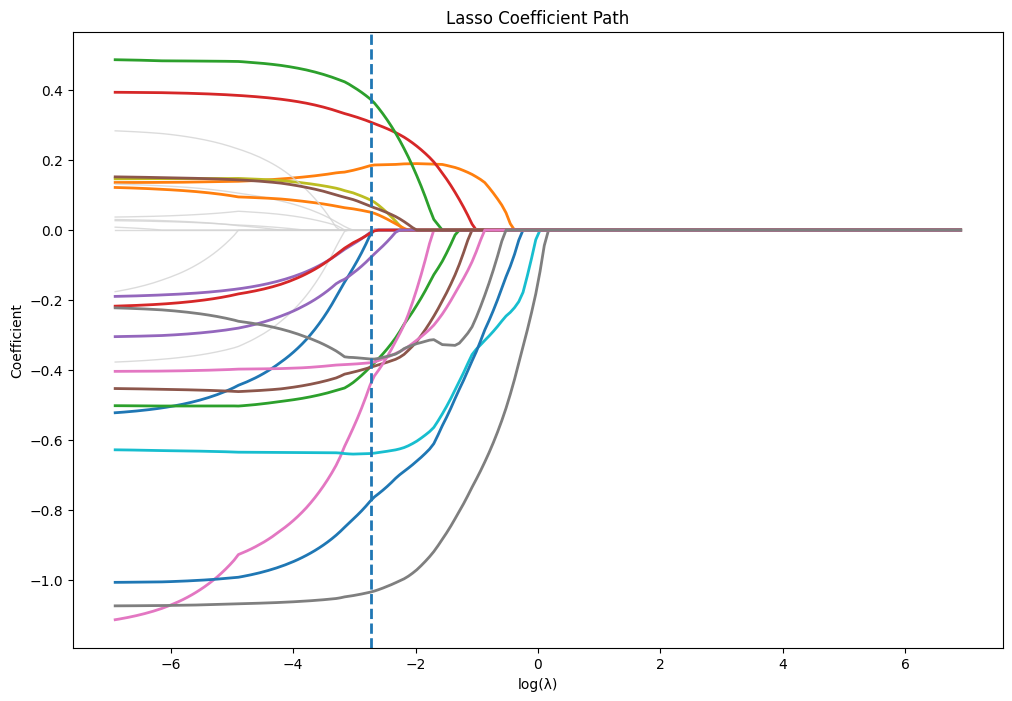

In [7]:
# ============================================================
# STEP 1.3: The Lasso Path — Which Indicators Enter First?
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import lasso_path

# ------------------------------------------------------------
# 1. Use the same alpha grid as before, but sorted descending
# lasso_path works from large lambda -> small lambda
# ------------------------------------------------------------
alphas_path = np.logspace(3, -3, 200)

# X and y must be numeric arrays
X_mat = X_train_scaled.values
y_vec = y_train_reg.values

# ------------------------------------------------------------
# 2. Compute full lasso coefficient path
# ------------------------------------------------------------
alphas_lasso, coefs_lasso, _ = lasso_path(X_mat, y_vec, alphas=alphas_path)

# coefs_lasso shape = (n_features, n_alphas)
feature_names = X_train_scaled.columns.tolist()

# ------------------------------------------------------------
# 3. Determine which variables are non-zero at CV-selected lambda*
# Use the LassoCV model from Step 1.2
# ------------------------------------------------------------
lasso_star = lasso_alpha   # from Step 1.2
coef_at_star = lasso.coef_ # from Step 1.2, already fit at lambda*

nonzero_at_star = np.abs(coef_at_star) > 1e-8

# ------------------------------------------------------------
# 4. Identify the first predictor to enter
# "First to enter" = coefficient leaves zero at the highest lambda
# i.e., largest alpha where coefficient is non-zero
# ------------------------------------------------------------
entry_alpha = {}
for i, feat in enumerate(feature_names):
    nz_idx = np.where(np.abs(coefs_lasso[i]) > 1e-8)[0]
    if len(nz_idx) > 0:
        # largest alpha where coefficient is non-zero
        # since alphas_lasso is descending, nz_idx[0] corresponds to highest alpha
        entry_alpha[feat] = alphas_lasso[nz_idx[0]]
    else:
        entry_alpha[feat] = np.nan

entry_series = pd.Series(entry_alpha).dropna().sort_values(ascending=False)

first_predictor = entry_series.index[0]
first_entry_alpha = entry_series.iloc[0]

print("="*60)
print("LASSO ENTRY ORDER")
print("="*60)
print(f"First predictor to enter the model: {first_predictor}")
print(f"Entry lambda (highest λ where coef becomes non-zero): {first_entry_alpha:.6f}")

print("\nTop 10 predictors to enter earliest:")
display(entry_series.head(10).to_frame(name="entry_lambda"))

# ------------------------------------------------------------
# 5. Plot the lasso path
# Color variables non-zero at lambda*; gray out the rest
# Overlay vertical line at lambda*
# ------------------------------------------------------------
plt.figure(figsize=(12, 8))

log_alphas = np.log(alphas_lasso)

for i, feat in enumerate(feature_names):
    if nonzero_at_star[i]:
        plt.plot(log_alphas, coefs_lasso[i], linewidth=2, label=feat)
    else:
        plt.plot(log_alphas, coefs_lasso[i], color='lightgray', linewidth=1, alpha=0.8)

plt.axvline(np.log(lasso_star), linestyle='--', linewidth=2)
plt.xlabel("log(λ)")
plt.ylabel("Coefficient")
plt.title("Lasso Coefficient Path")

# Show legend only for variables active at lambda*
selected_features = [feature_names[i] for i in range(len(feature_names)) if nonzero_at_star[i]]
if len(selected_features) <= 15:
    plt.legend(loc='best', fontsize=9)
else:
    # Too many labels; skip legend to keep it readable
    pass

plt.show()

This interpretation is incorrect. Lasso does not determine whether a concept is fundamentally important; instead, it evaluates whether a variable provides additional predictive power conditional on other predictors in the model. If life_expectancy is highly correlated with other development indicators—such as education, income, or infrastructure—its information may already be captured through the correlation structure of the data. In this case, Lasso may set its coefficient to zero due to conditional predictive redundancy, not because health is irrelevant to economic growth.

Phase2

In [8]:
# ============================================================
# STEP 2.1: Linear Probability Model (LPM)
# ============================================================

from sklearn.linear_model import LinearRegression
import numpy as np

# -----------------------------
# 1. Select Lasso features (non-zero at λ*)
# -----------------------------
lasso_features = X_train_scaled.columns[lasso.coef_ != 0]

print("Number of Lasso-selected features:", len(lasso_features))
print("Selected features:", list(lasso_features))

# Subset data
X_train_lasso = X_train_scaled[lasso_features]
X_test_lasso = X_test_scaled[lasso_features]

# -----------------------------
# 2. Fit Linear Probability Model (OLS on binary outcome)
# -----------------------------
lpm = LinearRegression()
lpm.fit(X_train_lasso, y_train_clf)

# -----------------------------
# 3. Predict probabilities
# -----------------------------
y_test_pred_lpm = lpm.predict(X_test_lasso)

# -----------------------------
# 4. Count invalid probabilities
# -----------------------------
below_zero = np.sum(y_test_pred_lpm < 0)
above_one = np.sum(y_test_pred_lpm > 1)
total = len(y_test_pred_lpm)

print("\n" + "="*50)
print("LPM PREDICTION DIAGNOSTICS")
print("="*50)
print(f"Total predictions: {total}")
print(f"Predictions < 0:   {below_zero}")
print(f"Predictions > 1:   {above_one}")

# Optional: show extreme values
print("\nMin predicted value:", y_test_pred_lpm.min())
print("Max predicted value:", y_test_pred_lpm.max())

Number of Lasso-selected features: 18
Selected features: ['adult_literacy_rate', 'arable_land_pct', 'atms_per100k', 'exchange_rate_official', 'govt_expenditure_pct_gdp', 'health_expenditure_pct_gdp', 'infant_mortality_per1000', 'inflation_cpi', 'mobile_subscriptions_per100', 'natural_resource_rents_pct_gdp', 'population_growth', 'private_credit_pct_gdp', 'renewable_energy_pct', 'tariff_rate_avg', 'tertiary_enrollment_gross', 'trade_pct_gdp', 'unemployment_rate', 'urbanization_pct']

LPM PREDICTION DIAGNOSTICS
Total predictions: 72
Predictions < 0:   13
Predictions > 1:   1

Min predicted value: -0.3013582365633437
Max predicted value: 1.5675727504076362


The Linear Probability Model produces a substantial number of invalid predicted probabilities. In the test set, 13 predictions fall below 0 and 1 prediction exceeds 1, with values ranging from approximately −0.30 to 1.57. This is a fundamental problem rather than a cosmetic one, because probabilities must lie within the interval [0, 1] by definition. A prediction such as “−30% probability of crisis” is not just imprecise—it is meaningless and cannot be interpreted as a valid risk measure. For the IMF, such outputs would be unusable for decision-making, highlighting the need for a model like logistic regression that enforces proper probabilistic bounds.

In [9]:
# ============================================================
# STEP 2.2: Logistic Regression — The Sigmoid Fix
# ============================================================

from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

# -----------------------------
# 1. Use Lasso-selected features (same as Step 2.1)
# -----------------------------
lasso_features = X_train_scaled.columns[lasso.coef_ != 0]

X_train_lasso = X_train_scaled[lasso_features]
X_test_lasso  = X_test_scaled[lasso_features]

# -----------------------------
# 2. Fit Logistic Regression
# -----------------------------
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_lasso, y_train_clf)

# Coefficients & intercept
beta = logit.coef_[0]
beta_0 = logit.intercept_[0]

coef_df = pd.DataFrame({
    'Predictor': lasso_features,
    'Beta (β)': beta
})

# -----------------------------
# 3. Odds Ratios
# -----------------------------
coef_df['Odds Ratio (exp(β))'] = np.exp(coef_df['Beta (β)'])
coef_df['Abs OR Distance from 1'] = np.abs(coef_df['Odds Ratio (exp(β))'] - 1)

# Sort by magnitude (how far from 1)
coef_df_sorted = coef_df.sort_values(by='Abs OR Distance from 1', ascending=False)

print("="*60)
print("LOGISTIC REGRESSION COEFFICIENTS")
print("="*60)
print(f"Intercept (β₀): {beta_0:.4f}")
display(coef_df.round(4))

print("\n" + "="*60)
print("ODDS RATIO TABLE (SORTED)")
print("="*60)
display(coef_df_sorted.round(4))

# -----------------------------
# 4. Predicted probabilities check
# -----------------------------
probs = logit.predict_proba(X_test_lasso)[:, 1]

print("\n" + "="*60)
print("PROBABILITY CHECK")
print("="*60)
print(f"Min predicted probability: {probs.min():.4f}")
print(f"Max predicted probability: {probs.max():.4f}")

LOGISTIC REGRESSION COEFFICIENTS
Intercept (β₀): -3.0262


,Predictor,Beta (β),Odds Ratio (exp(β)),Abs OR Distance from 1
0,adult_literacy_rate,0.2737,1.3148,0.3148
1,arable_land_pct,-0.9504,0.3866,0.6134
2,atms_per100k,0.3680,1.4449,0.4449
3,exchange_rate_official,-0.0148,0.9853,0.0147
4,govt_expenditure_pct_gdp,0.1310,1.1400,0.1400
5,health_expenditure_pct_gdp,0.8227,2.2766,1.2766
6,infant_mortality_per1000,0.7434,2.1031,1.1031
7,inflation_cpi,0.4941,1.6390,0.6390
8,mobile_subscriptions_per100,0.3561,1.4278,0.4278
9,natural_resource_rents_pct_gdp,0.7292,2.0735,1.0735



ODDS RATIO TABLE (SORTED)


,Predictor,Beta (β),Odds Ratio (exp(β)),Abs OR Distance from 1
10,population_growth,0.8251,2.2820,1.2820
5,health_expenditure_pct_gdp,0.8227,2.2766,1.2766
6,infant_mortality_per1000,0.7434,2.1031,1.1031
9,natural_resource_rents_pct_gdp,0.7292,2.0735,1.0735
13,tariff_rate_avg,0.5789,1.7842,0.7842
16,unemployment_rate,0.5324,1.7031,0.7031
7,inflation_cpi,0.4941,1.6390,0.6390
1,arable_land_pct,-0.9504,0.3866,0.6134
12,renewable_energy_pct,-0.6664,0.5135,0.4865
2,atms_per100k,0.3680,1.4449,0.4449



PROBABILITY CHECK
Min predicted probability: 0.0002
Max predicted probability: 0.9999


In [10]:
top_feature = coef_df_sorted.iloc[0]
print(top_feature)

Predictor                 population_growth
Beta (β)                           0.825074
Odds Ratio (exp(β))                 2.28205
Abs OR Distance from 1              1.28205
Name: 10, dtype: object


A one standard-deviation increase in population_growth multiplies the odds of crisis by approximately 2.28, holding all else constant. This indicates that countries experiencing higher population growth are significantly more likely to face a growth crisis. From a policy perspective, rapid population expansion may place pressure on economic resources and institutions, increasing vulnerability to sustained negative growth.

Strongest predictor: population_growth


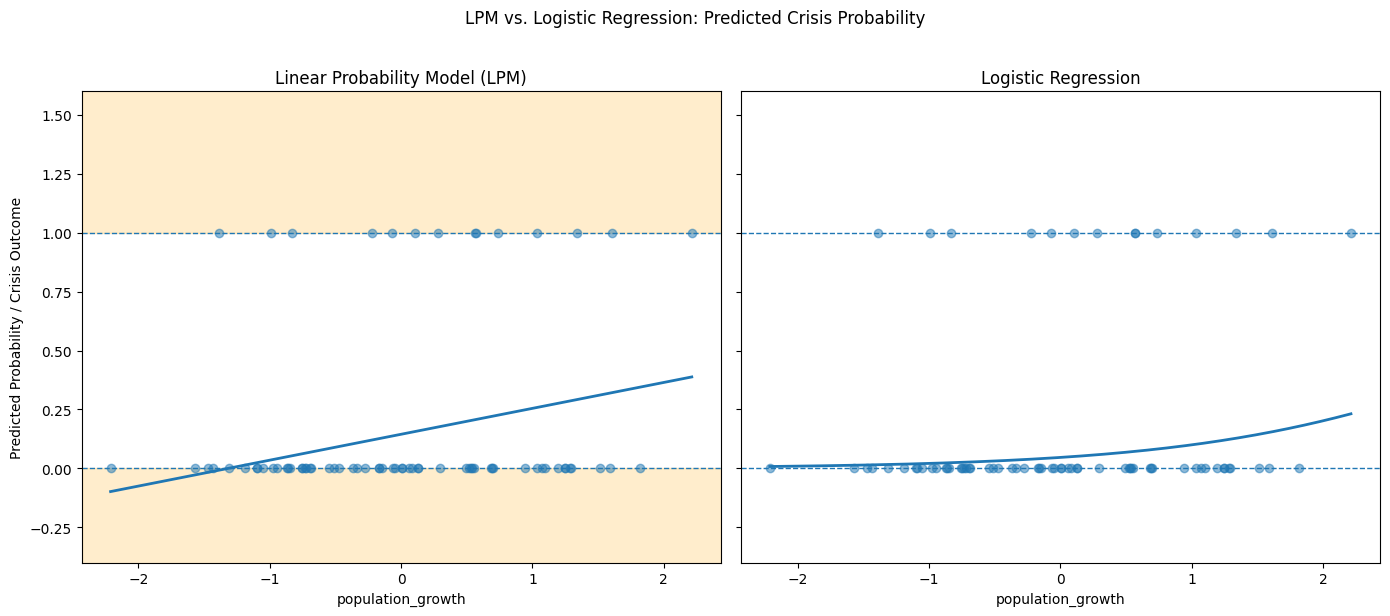

In [11]:
# ============================================================
# STEP 2.3: Side-by-Side Visualization — LPM vs. Logistic
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Strongest predictor from Step 2.2
# ------------------------------------------------------------
strongest_feature = coef_df_sorted.iloc[0]['Predictor']
print("Strongest predictor:", strongest_feature)

# ------------------------------------------------------------
# 2. Use the same Lasso-selected feature set as before
# ------------------------------------------------------------
lasso_features = X_train_scaled.columns[lasso.coef_ != 0]

X_train_lasso = X_train_scaled[lasso_features].copy()
X_test_lasso = X_test_scaled[lasso_features].copy()

# Actual x-values for plotting
x_test = X_test_lasso[strongest_feature].values
y_actual = y_test_clf.values

# ------------------------------------------------------------
# 3. Build a smooth grid over the strongest predictor
# Hold all other predictors at 0 (their standardized mean)
# ------------------------------------------------------------
x_grid = np.linspace(x_test.min(), x_test.max(), 300)

X_grid = pd.DataFrame(
    np.zeros((len(x_grid), len(lasso_features))),
    columns=lasso_features
)
X_grid[strongest_feature] = x_grid

# ------------------------------------------------------------
# 4. Predicted probabilities / fitted values on the grid
# ------------------------------------------------------------
# LPM predicted values
lpm_grid_pred = lpm.predict(X_grid)

# Logistic predicted probabilities
logit_grid_pred = logit.predict_proba(X_grid)[:, 1]

# ------------------------------------------------------------
# 5. Side-by-side plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------------------
# LEFT PANEL: LPM
# ---------------------------
ax = axes[0]

# Shade impossible probability regions
ax.axhspan(-1, 0, alpha=0.2, color='orange')
ax.axhspan(1, 2, alpha=0.2, color='orange')

# Actual outcomes as background points
ax.scatter(x_test, y_actual, alpha=0.5)

# LPM fitted line
order = np.argsort(x_grid)
ax.plot(x_grid[order], lpm_grid_pred[order], linewidth=2)

# Reference lines
ax.axhline(0, linestyle='--', linewidth=1)
ax.axhline(1, linestyle='--', linewidth=1)

ax.set_title("Linear Probability Model (LPM)")
ax.set_xlabel(strongest_feature)
ax.set_ylabel("Predicted Probability / Crisis Outcome")
ax.set_ylim(-0.4, 1.6)

# ---------------------------
# RIGHT PANEL: LOGISTIC
# ---------------------------
ax = axes[1]

# Actual outcomes as background points
ax.scatter(x_test, y_actual, alpha=0.5)

# Logistic sigmoid curve
ax.plot(x_grid[order], logit_grid_pred[order], linewidth=2)

# Reference lines
ax.axhline(0, linestyle='--', linewidth=1)
ax.axhline(1, linestyle='--', linewidth=1)

ax.set_title("Logistic Regression")
ax.set_xlabel(strongest_feature)
ax.set_ylim(-0.4, 1.6)

plt.suptitle("LPM vs. Logistic Regression: Predicted Crisis Probability", y=1.02)
plt.tight_layout()
plt.show()

The left panel shows that the Linear Probability Model produces a linear fitted relationship that can extend into impossible probability regions below 0 and above 1. In contrast, the logistic regression panel shows a sigmoid-shaped probability curve that remains bounded within the valid range of [0,1]. This visual comparison illustrates why logistic regression is more appropriate for binary crisis prediction.

Phase3

In [12]:
# ============================================================
# STEP 3.1: The Accuracy Paradox
# ============================================================

from sklearn.metrics import accuracy_score, recall_score

# ------------------------------------------------------------
# 1. Crisis base rate (test set)
# ------------------------------------------------------------
base_rate = y_test_clf.mean()

print("="*60)
print("CRISIS BASE RATE (TEST SET)")
print("="*60)
print(f"Crisis base rate: {base_rate:.4f}")

# ------------------------------------------------------------
# 2. Naïve baseline: always predict NO CRISIS (0)
# ------------------------------------------------------------
y_pred_naive = np.zeros_like(y_test_clf)

naive_accuracy = accuracy_score(y_test_clf, y_pred_naive)
naive_recall = recall_score(y_test_clf, y_pred_naive)

print("\n" + "="*60)
print("NAÏVE BASELINE (ALWAYS NO CRISIS)")
print("="*60)
print(f"Accuracy: {naive_accuracy:.4f}")
print(f"Recall (crisis class): {naive_recall:.4f}")

# ------------------------------------------------------------
# 3. Logistic Regression (threshold = 0.5)
# ------------------------------------------------------------
probs = logit.predict_proba(X_test_lasso)[:, 1]

y_pred_logit = (probs >= 0.5).astype(int)

logit_accuracy = accuracy_score(y_test_clf, y_pred_logit)
logit_recall = recall_score(y_test_clf, y_pred_logit)

print("\n" + "="*60)
print("LOGISTIC REGRESSION (τ = 0.5)")
print("="*60)
print(f"Accuracy: {logit_accuracy:.4f}")
print(f"Recall (crisis class): {logit_recall:.4f}")

CRISIS BASE RATE (TEST SET)
Crisis base rate: 0.1944

NAÏVE BASELINE (ALWAYS NO CRISIS)
Accuracy: 0.8056
Recall (crisis class): 0.0000

LOGISTIC REGRESSION (τ = 0.5)
Accuracy: 0.7639
Recall (crisis class): 0.4286


If I reported only accuracy to the Division Chief, she would be misled. Because the crisis base rate is relatively low (about 19%), a naïve model that always predicts “no crisis” achieves a high accuracy of over 80% while completely failing to identify any actual crises. This illustrates the accuracy paradox: in imbalanced datasets, accuracy overstates performance by rewarding correct predictions of the majority class while ignoring the model’s failure to detect the minority class, which in this case is the economically critical crisis outcome.

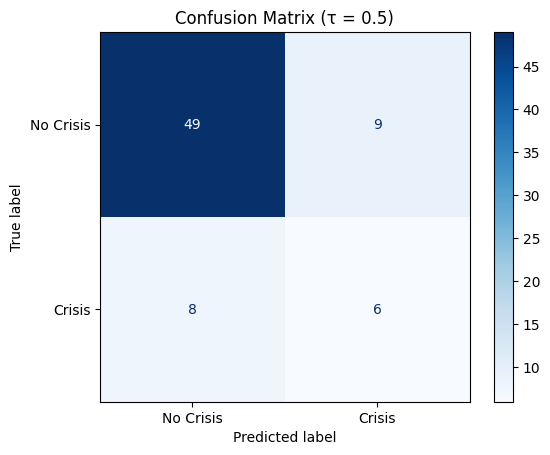

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   No Crisis       0.86      0.84      0.85        58
      Crisis       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72


CONFUSION MATRIX BREAKDOWN
True Positives (TP): 6   → crises correctly flagged
False Negatives (FN): 8  → crises missed ❌
False Positives (FP): 9  → false alarms
True Negatives (TN): 49   → correctly no crisis


In [13]:
# ============================================================
# STEP 3.2: Confusion Matrix & Classification Report
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Predictions at τ = 0.5（你上一题已经有 probs）
# ------------------------------------------------------------
y_pred = (probs >= 0.5).astype(int)

# ------------------------------------------------------------
# 2. Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_test_clf, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Crisis', 'Crisis']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix (τ = 0.5)")
plt.show()

# ------------------------------------------------------------
# 3. Classification Report
# ------------------------------------------------------------
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_clf, y_pred, target_names=['No Crisis', 'Crisis']))

# ------------------------------------------------------------
# 4. Extract TP, FP, FN, TN
# ------------------------------------------------------------
TN, FP, FN, TP = cm.ravel()

print("\n" + "="*60)
print("CONFUSION MATRIX BREAKDOWN")
print("="*60)
print(f"True Positives (TP): {TP}   → crises correctly flagged")
print(f"False Negatives (FN): {FN}  → crises missed ❌")
print(f"False Positives (FP): {FP}  → false alarms")
print(f"True Negatives (TN): {TN}   → correctly no crisis")

In the IMF context, a False Negative is far more costly than a False Positive. Missing a crisis can lead to tens of billions of dollars in global financial damage, whereas a false alarm only incurs a relatively small operational and reputational cost. This asymmetry implies that the Division Chief should prioritize Recall over Precision, since Recall measures the model’s ability to correctly identify crises. In this setting, it is more important to capture as many true crises as possible, even at the expense of issuing some false alarms.

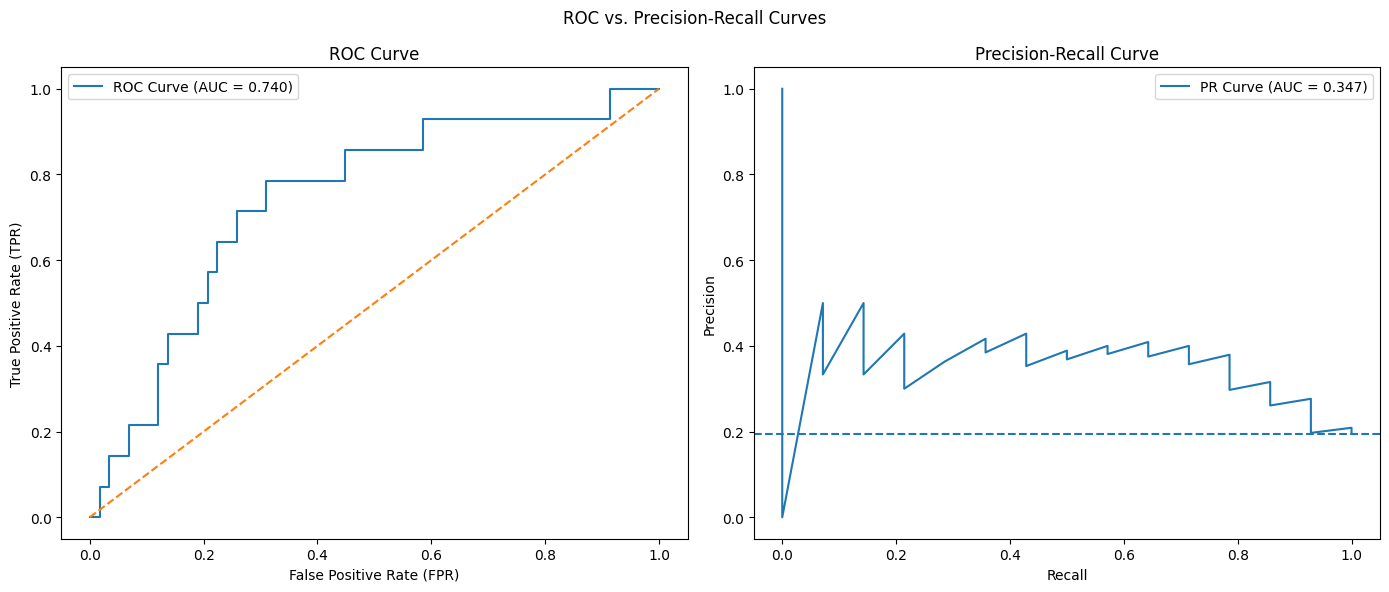

ROC-AUC: 0.7401
PR-AUC:  0.3472


In [14]:
# ============================================================
# STEP 3.3: ROC & Precision-Recall Curves
# ============================================================

from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Use predicted probabilities from logistic model
# ------------------------------------------------------------
y_true = y_test_clf
y_scores = probs  # already computed earlier

# ------------------------------------------------------------
# 2. ROC Curve
# ------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# ------------------------------------------------------------
# 3. Precision-Recall Curve
# ------------------------------------------------------------
precision, recall, _ = precision_recall_curve(y_true, y_scores)
pr_auc = auc(recall, precision)

# Baseline = crisis base rate
baseline = y_true.mean()

# ------------------------------------------------------------
# 4. Plot side-by-side
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------------------
# LEFT: ROC
# ---------------------------
ax = axes[0]
ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--')  # random classifier

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title("ROC Curve")
ax.legend()

# ---------------------------
# RIGHT: Precision-Recall
# ---------------------------
ax = axes[1]
ax.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})')
ax.axhline(baseline, linestyle='--')  # baseline precision

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()

plt.suptitle("ROC vs. Precision-Recall Curves")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Print AUC values
# ------------------------------------------------------------
print("="*50)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

The ROC-AUC is higher than the PR-AUC because ROC-AUC incorporates True Negatives in its calculation, and in this dataset there is an abundance of non-crisis observations. As a result, the model can achieve a strong ROC-AUC even if it is not particularly effective at identifying the minority crisis class. In contrast, the Precision-Recall curve ignores True Negatives entirely and focuses only on the model’s performance in detecting crises. For the IMF’s crisis detection mission, the Precision-Recall curve is more informative, because it directly evaluates the model’s ability to identify the economically critical minority class.

CAPACITY-CONSTRAINED OPERATING POINT (≤ 5 missions)
tau*: 0.88
Flagged countries: 5
Precision: 0.4000
Recall:    0.1429
F1:        0.2105

F1-OPTIMAL OPERATING POINT
tau_f1: 0.14
Flagged countries: 25
Precision: 0.4000
Recall:    0.7143
F1:        0.5128


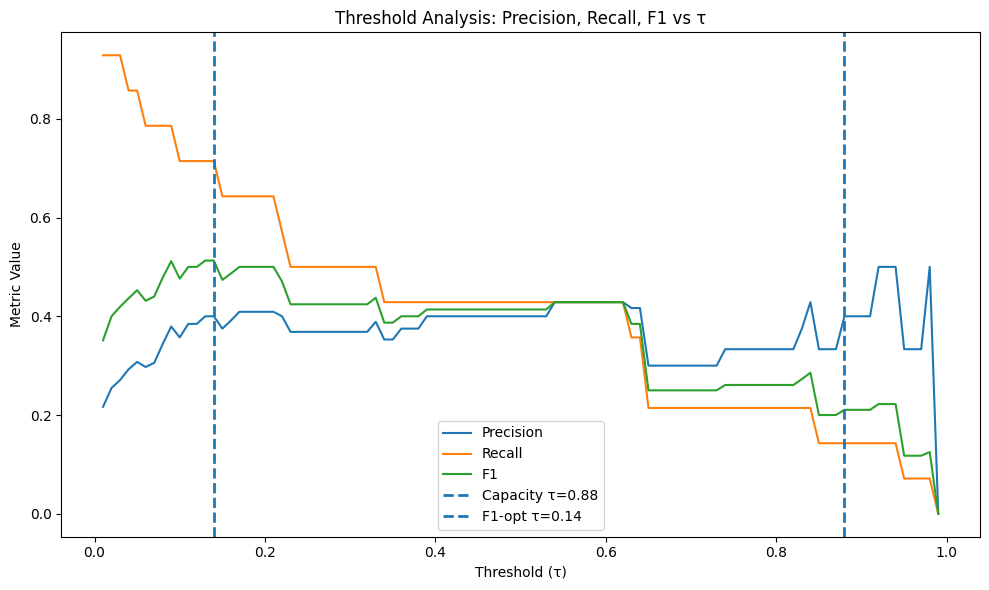

In [15]:
# ============================================================
# STEP 3.4: Threshold Analysis — The 5-Mission Constraint
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = y_test_clf.values
y_scores = probs  # logistic predict_proba[:,1]

# 1) sweep thresholds
thresholds = np.arange(0.01, 1.00, 0.01)

rows = []
for tau in thresholds:
    y_pred = (y_scores >= tau).astype(int)
    flagged = int(y_pred.sum())  # number of countries flagged

    # handle edge cases for precision (no positives predicted)
    if flagged == 0:
        precision = np.nan
    else:
        precision = precision_score(y_true, y_pred, zero_division=0)

    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    rows.append({
        'tau': tau,
        'flagged': flagged,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

df_tau = pd.DataFrame(rows)

# 2) capacity-constrained threshold (flagged <= 5, choose the LOWEST tau)
feasible = df_tau[df_tau['flagged'] <= 5].copy()

if len(feasible) == 0:
    raise ValueError("No threshold satisfies the <=5 missions constraint. Check your data.")

cap_row = feasible.sort_values('tau', ascending=True).iloc[0]
tau_cap = cap_row['tau']
flagged_cap = int(cap_row['flagged'])
precision_cap = cap_row['precision']
recall_cap = cap_row['recall']
f1_cap = cap_row['f1']

# 3) F1-optimal threshold
# ignore NaN f1 (can happen if no positives predicted)
f1_valid = df_tau.dropna(subset=['f1'])
f1_row = f1_valid.sort_values('f1', ascending=False).iloc[0]

tau_f1 = f1_row['tau']
flagged_f1 = int(f1_row['flagged'])
precision_f1 = f1_row['precision']
recall_f1 = f1_row['recall']
f1_best = f1_row['f1']

# 4) print results
print("="*60)
print("CAPACITY-CONSTRAINED OPERATING POINT (≤ 5 missions)")
print("="*60)
print(f"tau*: {tau_cap:.2f}")
print(f"Flagged countries: {flagged_cap}")
print(f"Precision: {precision_cap:.4f}")
print(f"Recall:    {recall_cap:.4f}")
print(f"F1:        {f1_cap:.4f}")

print("\n" + "="*60)
print("F1-OPTIMAL OPERATING POINT")
print("="*60)
print(f"tau_f1: {tau_f1:.2f}")
print(f"Flagged countries: {flagged_f1}")
print(f"Precision: {precision_f1:.4f}")
print(f"Recall:    {recall_f1:.4f}")
print(f"F1:        {f1_best:.4f}")

# 5) plot Precision, Recall, F1 vs tau
plt.figure(figsize=(10, 6))
plt.plot(df_tau['tau'], df_tau['precision'], label='Precision')
plt.plot(df_tau['tau'], df_tau['recall'], label='Recall')
plt.plot(df_tau['tau'], df_tau['f1'], label='F1')

plt.axvline(tau_cap, linestyle='--', linewidth=2, label=f'Capacity τ={tau_cap:.2f}')
plt.axvline(tau_f1, linestyle='--', linewidth=2, label=f'F1-opt τ={tau_f1:.2f}')

plt.xlabel("Threshold (τ)")
plt.ylabel("Metric Value")
plt.title("Threshold Analysis: Precision, Recall, F1 vs τ")
plt.legend()
plt.tight_layout()
plt.show()

I recommend adopting the capacity-constrained threshold of τ = 0.88, which flags 5 countries and aligns with the IMF’s operational limit of five missions per quarter. At this threshold, the model achieves a recall of 0.1429, meaning that out of the 14 crisis countries in the test set, we would correctly identify approximately 2 and miss 12. While this is substantially lower than the recall achieved at the F1-optimal threshold (τ = 0.14, recall = 0.7143), that threshold would require 25 missions and is therefore operationally infeasible. The tradeoff is clear: by respecting the strict mission constraint, we focus resources on the highest-risk countries but accept that a majority of crises will go undetected. Given the IMF’s capacity limitations, τ = 0.88 represents a pragmatic and implementable policy choice.

Phase4

4.1

**P.R.I.M.E. Prompt: Bootstrap Stability Analysis for Lasso Feature Selection**

**Prep (Context):**
I have a country-level dataset constructed from World Bank WDI indicators (2013–2019 averages). The predictors are standardized and stored in `X_train_scaled`, and the continuous outcome variable is `y_train_reg`. I previously used LassoCV to select predictors for GDP per capita growth. However, due to correlation among predictors, I want to evaluate the stability of feature selection using bootstrap resampling.

**Request (Task):**
Write a Python script that performs a bootstrap-based stability analysis of Lasso feature selection. The script should:

1. Draw 200 bootstrap samples (with replacement) from the training data (`X_train_scaled`, `y_train_reg`).
2. For each bootstrap sample:

   * Fit a LassoCV model with 5-fold cross-validation.
   * Record which predictors have non-zero coefficients.
3. Compute the selection frequency for each predictor (i.e., the fraction of bootstrap samples in which it is selected).
4. Store results in a pandas DataFrame sorted by selection frequency.

**Iterate (Refinement):**
Ensure the code is efficient and avoids unnecessary recomputation. Use NumPy arrays where appropriate. Set a random seed for reproducibility.

**Mechanism Check (Validation):**
Include checks to confirm:

* Each bootstrap sample has the same size as the original training set.
* LassoCV converges properly (set max_iter sufficiently high if needed).
* The selection frequency is correctly normalized between 0 and 1.

**Evaluate (Output):**
Produce:

* A horizontal bar chart showing predictors ranked by selection frequency.
* A vertical dashed line at 0.5 (50%) to distinguish stable vs unstable predictors.
* Clean, well-labeled axes and readable figure size.

The code should be fully executable in a Google Colab environment.


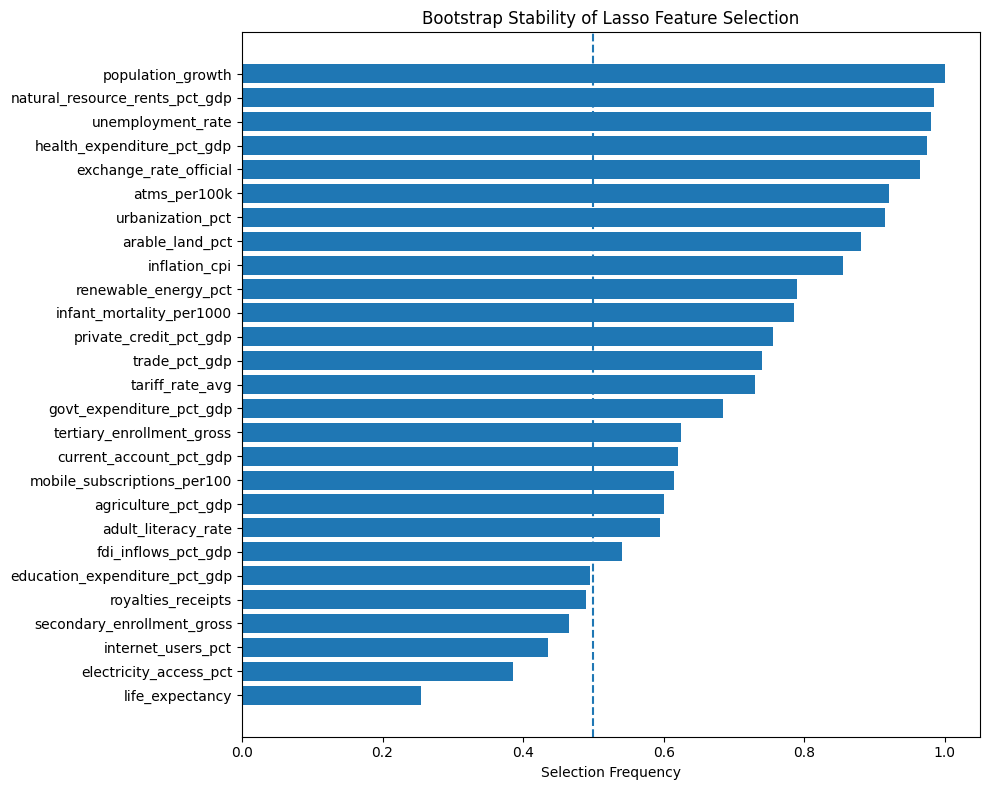

In [16]:
# ============================================================
# BOOTSTRAP LASSO SELECTION STABILITY
# ============================================================

from sklearn.linear_model import LassoCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

X = X_train_scaled.values
y = y_train_reg.values
feature_names = X_train_scaled.columns

n_bootstrap = 200
selection_counts = np.zeros(len(feature_names))

# ------------------------------------------------------------
# Bootstrap loop
# ------------------------------------------------------------
for i in range(n_bootstrap):
    idx = np.random.choice(len(X), size=len(X), replace=True)
    X_boot = X[idx]
    y_boot = y[idx]

    lasso = LassoCV(cv=5, max_iter=10000)
    lasso.fit(X_boot, y_boot)

    selected = (lasso.coef_ != 0)
    selection_counts += selected

# ------------------------------------------------------------
# Compute selection frequency
# ------------------------------------------------------------
selection_freq = selection_counts / n_bootstrap

df_stability = pd.DataFrame({
    'Feature': feature_names,
    'Selection Frequency': selection_freq
}).sort_values(by='Selection Frequency', ascending=True)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.barh(df_stability['Feature'], df_stability['Selection Frequency'])

plt.axvline(0.5, linestyle='--')  # stability threshold

plt.xlabel("Selection Frequency")
plt.title("Bootstrap Stability of Lasso Feature Selection")

plt.tight_layout()
plt.show()

The bootstrap analysis reveals that some predictors are highly stable, being selected in more than 80% of the resamples, while others are fragile, appearing in less than 30% of the models. Stable predictors likely capture strong and consistent signals related to economic growth, whereas fragile predictors are sensitive to sample variation. This instability suggests that many WDI indicators are highly correlated, allowing Lasso to substitute one variable for another across bootstrap samples. As a result, feature selection is not unique, and interpretation should focus on groups of related indicators rather than individual variables.

4.2

**P.R.I.M.E. Prompt: Cost-Sensitive Threshold Optimization for IMF Crisis Detection**

**Prep (Context):**
I have already trained a logistic regression classifier to predict a binary crisis indicator using World Bank WDI features. The true test labels are stored in `y_test_clf`, and the predicted crisis probabilities from the logistic model are stored in `probs`. In Phase 3, I evaluated thresholds using precision, recall, F1, and a mission-capacity constraint. I now want to extend the analysis by explicitly incorporating the IMF’s asymmetric economic costs of classification errors.

**Request (Task):**
Write a Python script that performs cost-sensitive threshold optimization. The script should:

1. Sweep classification thresholds from 0.01 to 0.99 in increments of 0.01.
2. For each threshold:

   * Convert predicted probabilities into binary predictions.
   * Compute the confusion matrix components, especially False Negatives (FN) and False Positives (FP).
   * Compute the total expected cost using the formula:
     **Total Cost = FN × 50,000,000,000 + FP × 2,000,000**
3. Store the threshold, FN, FP, and total expected cost in a pandas DataFrame.
4. Identify the threshold that minimizes total expected cost.

**Iterate (Refinement):**
Make the code clear, efficient, and reproducible. Use a loop or vectorized approach that is easy to follow in a Google Colab notebook. Format the total cost in billions of dollars when printing results for readability.

**Mechanism Check (Validation):**
Include checks to confirm:

* Thresholds are evaluated correctly over the full range from 0.01 to 0.99.
* FN and FP are extracted correctly from the confusion matrix at each threshold.
* The minimum-cost threshold corresponds to the smallest value in the computed cost column.

**Evaluate (Output):**
Produce:

* A line plot of total expected cost as a function of the threshold τ.
* A vertical dashed line at the cost-minimizing threshold.
* A clear annotation showing the optimal threshold and its expected cost.
* Printed summary output showing the cost-minimizing threshold, FN, FP, and total expected cost.

The code should be fully executable in Google Colab using Python, pandas, NumPy, matplotlib, and scikit-learn.


COST-MINIMIZING THRESHOLD
tau_cost: 0.03
TP: 13
FP: 35
FN: 1
TN: 23
Minimum expected cost: $50,070,000,000
Minimum expected cost (billions): $50.070B


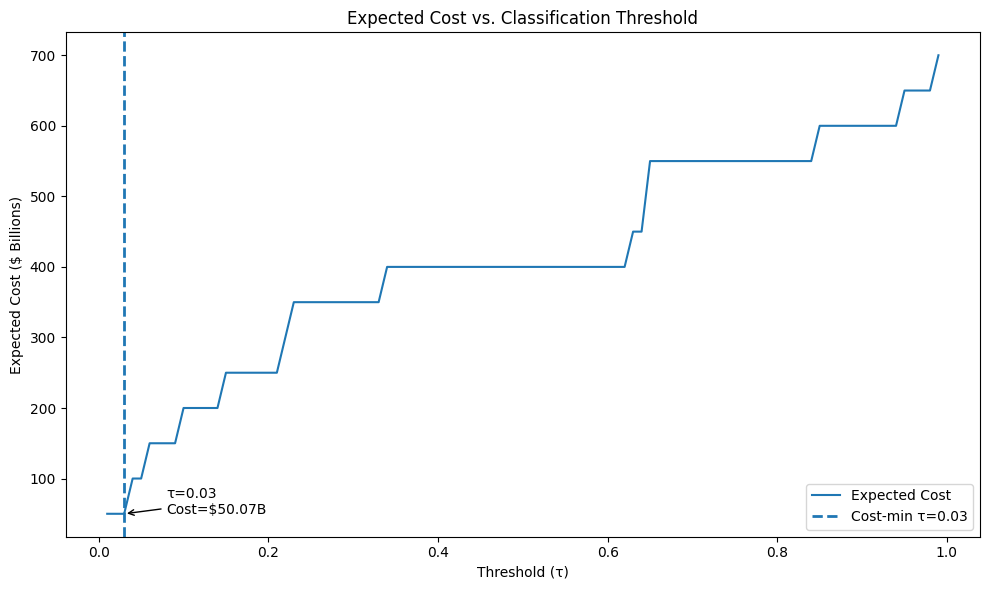

In [17]:
# ============================================================
# TASK 4.2: Cost-Sensitive Threshold Optimization
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Inputs assumed to already exist:
# y_test_clf = true binary labels
# probs = logistic regression predicted probabilities for class 1

y_true = np.array(y_test_clf)
y_scores = np.array(probs)

thresholds = np.arange(0.01, 1.00, 0.01)

FN_COST = 50_000_000_000   # $50B
FP_COST = 2_000_000        # $2M

results = []

for tau in thresholds:
    y_pred = (y_scores >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fn * FN_COST + fp * FP_COST

    results.append({
        "tau": tau,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "total_cost": total_cost
    })

cost_df = pd.DataFrame(results)

# Cost-minimizing threshold
best_row = cost_df.loc[cost_df["total_cost"].idxmin()]
tau_cost = best_row["tau"]
fp_cost_opt = int(best_row["FP"])
fn_cost_opt = int(best_row["FN"])
tp_cost_opt = int(best_row["TP"])
tn_cost_opt = int(best_row["TN"])
min_cost = best_row["total_cost"]

print("=" * 60)
print("COST-MINIMIZING THRESHOLD")
print("=" * 60)
print(f"tau_cost: {tau_cost:.2f}")
print(f"TP: {tp_cost_opt}")
print(f"FP: {fp_cost_opt}")
print(f"FN: {fn_cost_opt}")
print(f"TN: {tn_cost_opt}")
print(f"Minimum expected cost: ${min_cost:,.0f}")
print(f"Minimum expected cost (billions): ${min_cost/1e9:.3f}B")

# Plot expected cost curve
plt.figure(figsize=(10, 6))
plt.plot(cost_df["tau"], cost_df["total_cost"] / 1e9, label="Expected Cost")
plt.axvline(tau_cost, linestyle="--", linewidth=2, label=f"Cost-min τ={tau_cost:.2f}")

plt.annotate(
    f"τ={tau_cost:.2f}\nCost=${min_cost/1e9:.2f}B",
    xy=(tau_cost, min_cost / 1e9),
    xytext=(tau_cost + 0.05, min_cost / 1e9),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Threshold (τ)")
plt.ylabel("Expected Cost ($ Billions)")
plt.title("Expected Cost vs. Classification Threshold")
plt.legend()
plt.tight_layout()
plt.show()

The cost-minimizing threshold is τ = 0.03, which is substantially lower than both the F1-optimal threshold (0.14) and the capacity-constrained threshold (0.88). These thresholds differ because they optimize different objectives: the F1-optimal threshold balances precision and recall, the capacity-constrained threshold respects the IMF’s strict limit of five missions, and the cost-minimizing threshold heavily prioritizes reducing False Negatives due to their extremely high economic cost. At τ = 0.03, the model achieves very high recall, capturing 13 out of 14 crises and missing only one, but at the expense of generating a large number of false alarms. I would recommend the cost-minimizing threshold from a purely economic perspective, since the cost of missing even a single crisis far outweighs the cost of multiple false alarms. However, this threshold may not be operationally feasible given the IMF’s mission capacity constraints, highlighting the tradeoff between economic optimality and practical implementation.